# 17. Publicaciones

**Fuente:** `data/raw/publicaciones.csv`  
**Salida:** `data/processed/publicaciones.csv`

Publicaciones academicas del personal (articulos, libros, ponencias publicadas): titulo, tipo, anio, revista/base de indexacion, cuartil, factor de impacto.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('publicaciones.csv', low_memory=False)
df.head()

Leido publicaciones.csv con encoding=utf-8-sig -> 8757 filas, 28 columnas


,IDPUBLICACIONPERSONA,IDPERSONA,TITULO,TIPOPUBLICACION,ANIO,TIPOPARTICIPACION,NROISBN,ESTADOPUBLICACION,INSTITUCION,REVISIONPARES,BASEINDEXACION,NOMBREREVISTA,REVISTAINDEXADA,FACTORIMPACTOSJR,CUARTIL,FACTORIMPACTOCITESCORE,CUARTILCITESCORE,URLPUBLICACION,ENESCALAFON,REFARCHIVO1,REFARCHIVO2,REFARCHIVO3,TABLA,SISTEMA,STRTIPOPUBLICACION,STRTIPOPARTICIPACION,STRESTADOPUBLICACION,STRTIPOIDNEXACION
0,7404,26,SUBTHALAMIC NUCLEUS AND SUBSTANTIA NIGRA AUTOM...,ARTÍCULO CIENTÍFICO,2024,2,2367-3370,1.0,NaN,NaN,2.0,INFORMATION SYSTEMS AND TECHNOLOGIES,S,15,Q4,15,NaN,https://link.springer.com/chapter/10.1007/978-...,NaN,"7404,1",NaN,NaN,I,INVESTIGACION,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
1,7274,26,AN ARTIFICIAL INTELLIGENCE APPROACH FOR SEGMEN...,ARTÍCULO CIENTÍFICO,2023,2,21681163,1.0,NaN,NaN,2.0,COMPUTER METHODS IN BIOMECHANICS AND BIOMEDICA...,S,037,Q2,NaN,NaN,https://www.scopus.com/record/display.uri?eid=...,NaN,"7274,1","7274,2",NaN,I,INVESTIGACION,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
2,4874,26,THE MOTOR INHIBITORY NETWORK IN PATIENTS WITH ...,ARTÍCULO CIENTÍFICO,2022,1,"19317557, 19317565",1.0,NaN,NaN,2.0,BRAIN IMAGING AND BEHAVIOR,S,"1,980",Q1,NaN,NaN,https://doi.org/10.1007/s11682-021-00587-5,NaN,"4874,1",NaN,NaN,I,INVESTIGACION,ARTÍCULO CIENTÍFICO,Autor,Publicado,Scimago Journal Rank (scopus)
3,4875,26,BRAIN ACTIVITY AND FUNCTIONAL CONNECTIVITY PAT...,ARTÍCULO CIENTÍFICO,2022,2,16634365,1.0,NaN,NaN,2.0,FRONTIERS IN AGING NEUROSCIENCE,S,"1,808",Q1,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8...,NaN,"4875,1",NaN,NaN,I,INVESTIGACION,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
4,5013,26,IDENTIFICATION OF LOWER-LIMB MOTOR TASKS VIA B...,ARTÍCULO CIENTÍFICO,2022,2,"14220067, 16616596",1.0,NaN,NaN,2.0,MDPI MULTIDISCIPLINARY DIGITAL PUBLISHING INST...,S,"1,46",Q1,NaN,NaN,https://www.mdpi.com/1424-8220/22/5/2028/htm,NaN,"5013,1",NaN,NaN,I,INVESTIGACION,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'publicaciones')

--- Resumen publicaciones ---
Dimensiones: 8757 filas x 28 columnas
Filas duplicadas: 0
Columnas con nulos (%):
ENESCALAFON               95.7
REVISIONPARES             93.4
REFARCHIVO3               90.9
REFARCHIVO2               78.0
CUARTILCITESCORE          74.4
FACTORIMPACTOCITESCORE    68.7
INSTITUCION               65.6
STRTIPOIDNEXACION         41.9
STRESTADOPUBLICACION      36.3
FACTORIMPACTOSJR          28.3
CUARTIL                   16.6
BASEINDEXACION             9.4
NROISBN                    9.1
URLPUBLICACION             7.8
NOMBREREVISTA              5.9
ESTADOPUBLICACION          5.2
dtype: float64


In [4]:
df.dtypes

IDPUBLICACIONPERSONA        int64
IDPERSONA                   int64
TITULO                     object
TIPOPUBLICACION            object
ANIO                        int64
TIPOPARTICIPACION           int64
NROISBN                    object
ESTADOPUBLICACION         float64
INSTITUCION                object
REVISIONPARES              object
BASEINDEXACION            float64
NOMBREREVISTA              object
REVISTAINDEXADA            object
FACTORIMPACTOSJR           object
CUARTIL                    object
FACTORIMPACTOCITESCORE     object
CUARTILCITESCORE           object
URLPUBLICACION             object
ENESCALAFON                object
REFARCHIVO1                object
REFARCHIVO2                object
REFARCHIVO3                object
TABLA                      object
SISTEMA                    object
STRTIPOPUBLICACION         object
STRTIPOPARTICIPACION       object
STRESTADOPUBLICACION       object
STRTIPOIDNEXACION          object
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

Columnas eliminadas por ser constantes: ['TABLA', 'SISTEMA']


## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_enteros(df, ['IDPUBLICACIONPERSONA', 'IDPERSONA', 'ANIO'])
df = pc.convertir_sn_a_binario(df, ['REVISIONPARES', 'REVISTAINDEXADA', 'ENESCALAFON'])

Columnas S/N convertidas a binario (1/0): ['REVISIONPARES', 'REVISTAINDEXADA', 'ENESCALAFON']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Publicaciones por año**.

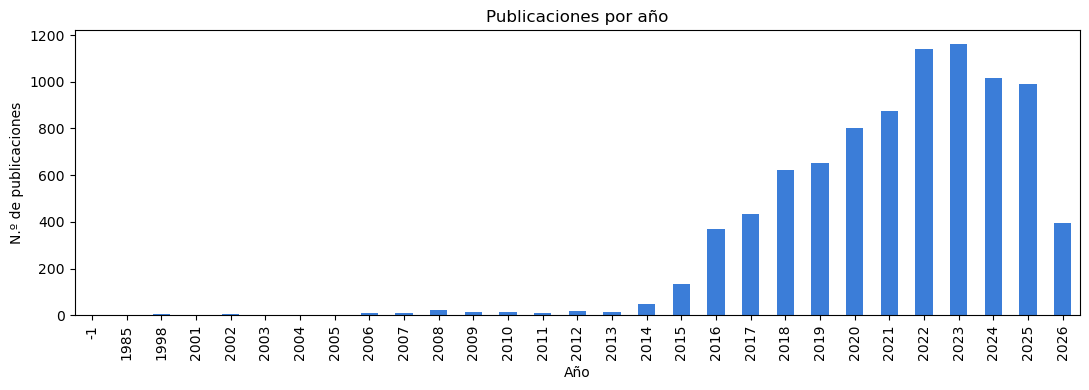

In [8]:
conteo_anio = df['ANIO'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4))
conteo_anio.plot(kind='bar', ax=ax, color=pc.COLOR_PRINCIPAL)
ax.set_title('Publicaciones por año')
ax.set_xlabel('Año'); ax.set_ylabel('N.º de publicaciones')
plt.tight_layout()

**Tipos de publicación más frecuentes**.

<Axes: title={'center': 'Top 10 tipos de publicación'}, ylabel='TIPOPUBLICACION'>

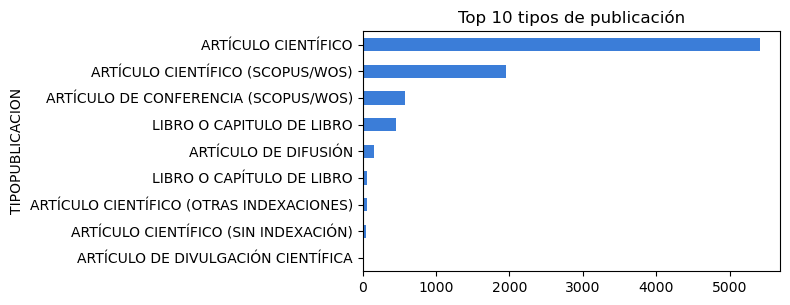

In [9]:
pc.grafico_barras(df['TIPOPUBLICACION'], 'Top 10 tipos de publicación', top=10)

**Distribución por cuartil** de la revista (cuando aplica).

<Axes: title={'center': 'Publicaciones por cuartil'}, xlabel='CUARTIL'>

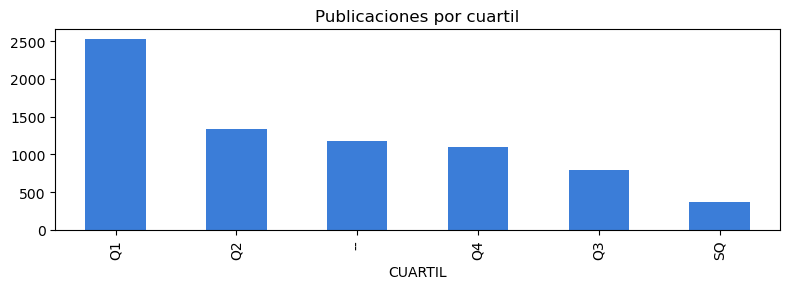

In [10]:
pc.grafico_barras(df['CUARTIL'], 'Publicaciones por cuartil', horizontal=False)

## 7. Verificación final

In [12]:
pc.resumen(df, 'publicaciones (procesado)')
df.head()

--- Resumen publicaciones (procesado) ---
Dimensiones: 8757 filas x 26 columnas
Filas duplicadas: 0
Columnas con nulos (%):
REFARCHIVO3               90.9
REFARCHIVO2               78.0
CUARTILCITESCORE          74.4
FACTORIMPACTOCITESCORE    68.7
INSTITUCION               65.6
STRTIPOIDNEXACION         41.9
STRESTADOPUBLICACION      36.3
FACTORIMPACTOSJR          28.3
CUARTIL                   16.6
BASEINDEXACION             9.4
NROISBN                    9.1
URLPUBLICACION             7.8
NOMBREREVISTA              5.9
ESTADOPUBLICACION          5.2
dtype: float64


,IDPUBLICACIONPERSONA,IDPERSONA,TITULO,TIPOPUBLICACION,ANIO,TIPOPARTICIPACION,NROISBN,ESTADOPUBLICACION,INSTITUCION,REVISIONPARES,BASEINDEXACION,NOMBREREVISTA,REVISTAINDEXADA,FACTORIMPACTOSJR,CUARTIL,FACTORIMPACTOCITESCORE,CUARTILCITESCORE,URLPUBLICACION,ENESCALAFON,REFARCHIVO1,REFARCHIVO2,REFARCHIVO3,STRTIPOPUBLICACION,STRTIPOPARTICIPACION,STRESTADOPUBLICACION,STRTIPOIDNEXACION
0,7404,26,SUBTHALAMIC NUCLEUS AND SUBSTANTIA NIGRA AUTOM...,ARTÍCULO CIENTÍFICO,2024,2,2367-3370,1.0,<NA>,0,2.0,INFORMATION SYSTEMS AND TECHNOLOGIES,1,15,Q4,15,<NA>,https://link.springer.com/chapter/10.1007/978-...,0,"7404,1",<NA>,<NA>,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
1,7274,26,AN ARTIFICIAL INTELLIGENCE APPROACH FOR SEGMEN...,ARTÍCULO CIENTÍFICO,2023,2,21681163,1.0,<NA>,0,2.0,COMPUTER METHODS IN BIOMECHANICS AND BIOMEDICA...,1,037,Q2,<NA>,<NA>,https://www.scopus.com/record/display.uri?eid=...,0,"7274,1","7274,2",<NA>,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
2,4874,26,THE MOTOR INHIBITORY NETWORK IN PATIENTS WITH ...,ARTÍCULO CIENTÍFICO,2022,1,"19317557, 19317565",1.0,<NA>,0,2.0,BRAIN IMAGING AND BEHAVIOR,1,"1,980",Q1,<NA>,<NA>,https://doi.org/10.1007/s11682-021-00587-5,0,"4874,1",<NA>,<NA>,ARTÍCULO CIENTÍFICO,Autor,Publicado,Scimago Journal Rank (scopus)
3,4875,26,BRAIN ACTIVITY AND FUNCTIONAL CONNECTIVITY PAT...,ARTÍCULO CIENTÍFICO,2022,2,16634365,1.0,<NA>,0,2.0,FRONTIERS IN AGING NEUROSCIENCE,1,"1,808",Q1,<NA>,<NA>,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8...,0,"4875,1",<NA>,<NA>,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)
4,5013,26,IDENTIFICATION OF LOWER-LIMB MOTOR TASKS VIA B...,ARTÍCULO CIENTÍFICO,2022,2,"14220067, 16616596",1.0,<NA>,0,2.0,MDPI MULTIDISCIPLINARY DIGITAL PUBLISHING INST...,1,"1,46",Q1,<NA>,<NA>,https://www.mdpi.com/1424-8220/22/5/2028/htm,0,"5013,1",<NA>,<NA>,ARTÍCULO CIENTÍFICO,CoAutor,Publicado,Scimago Journal Rank (scopus)


## 8. Guardado en data/processed

In [13]:
pc.guardar_procesado(df, 'publicaciones.csv')

Guardado: D:\Proyecto_Tesis\data\processed\publicaciones.csv (8757 filas x 26 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/publicaciones.csv')